# Trabalho Prático 1 - Classificação de Exoplanetas

**Nome:** Thiago Domingos Venturim Ribeiro dos Santos 

## Objetivo: 
Praticar os conceitos aprendidos na disciplina e adquirir experiência no uso
de alguns dos principais métodos de classificação, na avaliação de modelos e na interpretação e
apresentação de resultados de experimentos.

Para isso,  utilizar e comparar métodos de classificação baseados em princípios
diferentes em um problema de classificação binária de candidatos a exoplanetas. Além da
implementação dos modelos, deve estruturar um experimento
de aprendizado de máquina de forma adequada, justificando as decisões tomadas ao longo do
processo.


## Tarefas
Neste trabalho tem uma comparação entre os seguintes métodos de classificação:

• Naive Bayes
• Decision Tree
• k-Nearest Neighbors (k-NN)
• Support Vector Machines (SVM)
• Random Forest
• Gradient Tree Boosting

Pode ser necessário pré-processar os dados (por exemplo, normalização ou padronização) e testar diferentes valores para os hi-perparâmetros dos métodos para se obter bons resultados. Caso realize algum tipo de pré-
processamento, é necessário justificar sua escolha e explicar seu impacto no desempenho dos
modelos.

A avaliação dos métodos deverá ser feita utilizando validação cruzada k-fold com k=5. É importante garantir que o processo de validação seja realizado corretamente, evitando vazamento de dados (data leakage), especialmente nos casos em que houver etapas de pré-processamento.
Sempre que houver pré-processamento, este deve ser aplicado dentro do processo de validação (por exemplo, utilizando pipelines), e não antes da divisão dos dados.
A avaliação dos modelos não deve se limitar apenas à acurácia. Sempre que pertinente, utilize outras métricas, como precisão, revocação (recall) e F1-score, justificando a escolha das métricas de acordo com o problema. Discuta também possíveis limitações do uso exclusivo da acurácia. A escolha das métricas deve ser coerente com a distribuição das classes e com o tipo de erro que se deseja evitar.

Os experimentos a serem realizados para cada método são:

• Naive Bayes: experimento para servir de baseline

• Decision Tree: variar a altura máxima da árvore (inluindo permitir altura ilimitada) e
mostrar os resultados graficamente, discutindo o impacto desse hiperparâmetro no modelo
• SVM: avaliar os kernels linear, sigmoid, polinomial e RBF, explicando as diferenças entre
eles e seus efeitos nos resultados
• k-NN: variar o número k de vizinhos e mostrar os resultados graficamente, discutindo o
impacto da escolha de k
• Random Forest: variar o número de árvores e mostrar os resultados graficamente,
analisando o efeito na performance e estabilidade do modelo
• Gradient Tree Boosting: variar o número de iterações e mostrar os resultados grafi-
camente, discutindo possíveis efeitos de overfitting

### Pipeline utilizada 

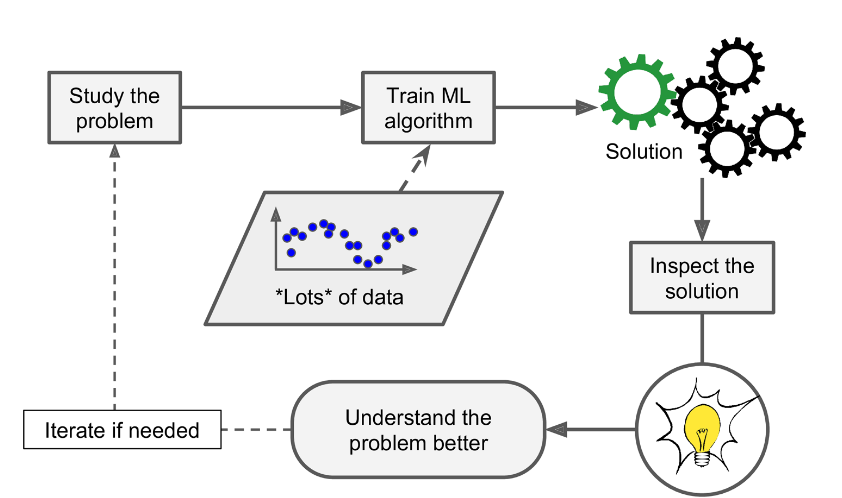

*Imagem retirada do livro Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow, 2nd Edition*


### Parte 1 - Exportando a Base de Dados e Estudo sobre o Problema

A primeira parte se concentra a exportação da base de dados e o estudo do problema, onde o objetivo e entender os registros e atributos que formam a base de dados

In [16]:
import pandas as pd  
import numpy as np
import matplotlib.pyplot as plt 

try:
    df = pd.read_csv('koi_data.csv')
    linhas , colunas = df.shape
    colunas_nome = df.columns
    print(f"Quantidade de linhas: {linhas} e colunas: {colunas}")
    print(f"Nomes das Colunas: {colunas_nome.values}")
except Exception as e:
    print(f'Base de Dados não encontrada {e}')



Quantidade de linhas: 5202 e colunas: 43
Nomes das Colunas: ['kepoi_name' 'koi_disposition' 'koi_period' 'koi_impact' 'koi_duration'
 'koi_depth' 'koi_ror' 'koi_srho' 'koi_prad' 'koi_sma' 'koi_incl'
 'koi_teq' 'koi_insol' 'koi_dor' 'koi_max_sngle_ev' 'koi_max_mult_ev'
 'koi_model_snr' 'koi_steff' 'koi_slogg' 'koi_smet' 'koi_srad' 'koi_smass'
 'koi_kepmag' 'koi_gmag' 'koi_rmag' 'koi_imag' 'koi_zmag' 'koi_jmag'
 'koi_hmag' 'koi_kmag' 'koi_fwm_stat_sig' 'koi_fwm_sra' 'koi_fwm_sdec'
 'koi_fwm_srao' 'koi_fwm_sdeco' 'koi_fwm_prao' 'koi_fwm_pdeco'
 'koi_dicco_mra' 'koi_dicco_mdec' 'koi_dicco_msky' 'koi_dikco_mra'
 'koi_dikco_mdec' 'koi_dikco_msky']


In [17]:
df.head(5)

,kepoi_name,koi_disposition,koi_period,koi_impact,koi_duration,koi_depth,koi_ror,koi_srho,koi_prad,koi_sma,...,koi_fwm_srao,koi_fwm_sdeco,koi_fwm_prao,koi_fwm_pdeco,koi_dicco_mra,koi_dicco_mdec,koi_dicco_msky,koi_dikco_mra,koi_dikco_mdec,koi_dikco_msky
0,K00752.01,CONFIRMED,9.48804,0.146,2.95750,615.8,0.02234,3.20796,2.26,0.0853,...,0.430,0.940,-0.00020,-0.00055,-0.010,0.200,0.200,0.080,0.310,0.320
1,K00752.02,CONFIRMED,54.41838,0.586,4.50700,874.8,0.02795,3.02368,2.83,0.2734,...,-0.630,1.230,0.00066,-0.00105,0.390,0.000,0.390,0.490,0.120,0.500
2,K00754.01,FALSE POSITIVE,1.73695,1.276,2.40641,8079.2,0.38739,0.22080,33.46,0.0267,...,-0.111,0.002,0.00302,-0.00142,-0.249,0.147,0.289,-0.257,0.099,0.276
3,K00755.01,CONFIRMED,2.52559,0.701,1.65450,603.3,0.02406,1.98635,2.75,0.0374,...,-0.010,0.230,0.00008,-0.00007,0.030,-0.090,0.100,0.070,0.020,0.070
4,K00114.01,FALSE POSITIVE,7.36179,1.169,5.02200,233.7,0.18339,0.00485,39.21,0.0820,...,-13.450,24.090,0.00303,-0.00555,-4.506,7.710,8.930,-4.537,7.713,8.948


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5202 entries, 0 to 5201
Data columns (total 43 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   kepoi_name        5202 non-null   object 
 1   koi_disposition   5202 non-null   object 
 2   koi_period        5202 non-null   float64
 3   koi_impact        5202 non-null   float64
 4   koi_duration      5202 non-null   float64
 5   koi_depth         5202 non-null   float64
 6   koi_ror           5202 non-null   float64
 7   koi_srho          5202 non-null   float64
 8   koi_prad          5202 non-null   float64
 9   koi_sma           5202 non-null   float64
 10  koi_incl          5202 non-null   float64
 11  koi_teq           5202 non-null   float64
 12  koi_insol         5202 non-null   float64
 13  koi_dor           5202 non-null   float64
 14  koi_max_sngle_ev  5202 non-null   float64
 15  koi_max_mult_ev   5202 non-null   float64
 16  koi_model_snr     5202 non-null   float64


In [19]:
df.describe()

,koi_period,koi_impact,koi_duration,koi_depth,koi_ror,koi_srho,koi_prad,koi_sma,koi_incl,koi_teq,...,koi_fwm_srao,koi_fwm_sdeco,koi_fwm_prao,koi_fwm_pdeco,koi_dicco_mra,koi_dicco_mdec,koi_dicco_msky,koi_dikco_mra,koi_dikco_mdec,koi_dikco_msky
count,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,...,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000
mean,37.032237,0.717106,5.607025,21340.318993,0.235205,3.415370,112.230798,0.158146,81.181413,1143.721069,...,-0.355681,-0.805629,-0.000263,0.000439,-0.049743,-0.087413,1.930251,-0.038402,-0.098738,1.920226
std,88.417985,2.628207,6.962634,66989.808550,2.586213,25.131368,3699.799318,0.241792,16.308839,775.788868,...,10.978677,14.741473,0.065707,0.077519,2.465670,2.746534,3.147553,2.465094,2.734732,3.142764
min,0.306940,0.000000,0.104600,0.800000,0.001290,0.000040,0.080000,0.007200,2.290000,92.000000,...,-275.600000,-397.620000,-4.000000,-0.800000,-21.500000,-75.900000,0.000000,-23.600000,-76.600000,0.000000
25%,2.213963,0.226000,2.500250,176.800000,0.013057,0.176092,1.460000,0.033000,81.930000,615.250000,...,-0.500000,-0.570000,-0.000240,-0.000240,-0.270000,-0.291500,0.128250,-0.265250,-0.320000,0.180000
50%,7.386755,0.610000,3.805500,495.950000,0.024185,0.748045,2.600000,0.073650,87.890000,948.000000,...,0.000000,-0.030000,0.000000,0.000000,0.000000,0.000000,0.460000,-0.007000,-0.018000,0.453000
75%,23.448118,0.923750,6.000750,2120.525000,0.171260,2.267062,21.645000,0.158200,89.520000,1482.000000,...,0.500000,0.450000,0.000260,0.000280,0.230000,0.230000,2.570000,0.226250,0.250000,2.420000
max,1071.232620,100.806000,138.540000,864260.000000,99.870650,918.752390,200346.000000,2.034500,90.000000,9791.000000,...,97.780000,98.780000,1.190000,5.000000,45.680000,27.500000,88.600000,46.570000,31.200000,89.600000


In [20]:
print(df['koi_disposition'].value_counts())
df_false_positive = df[df['koi_disposition'] == 'FALSE POSITIVE']
df_confirmed = df[df['koi_disposition'] == 'CONFIRMED']

koi_disposition
FALSE POSITIVE    3098
CONFIRMED         2104
Name: count, dtype: int64


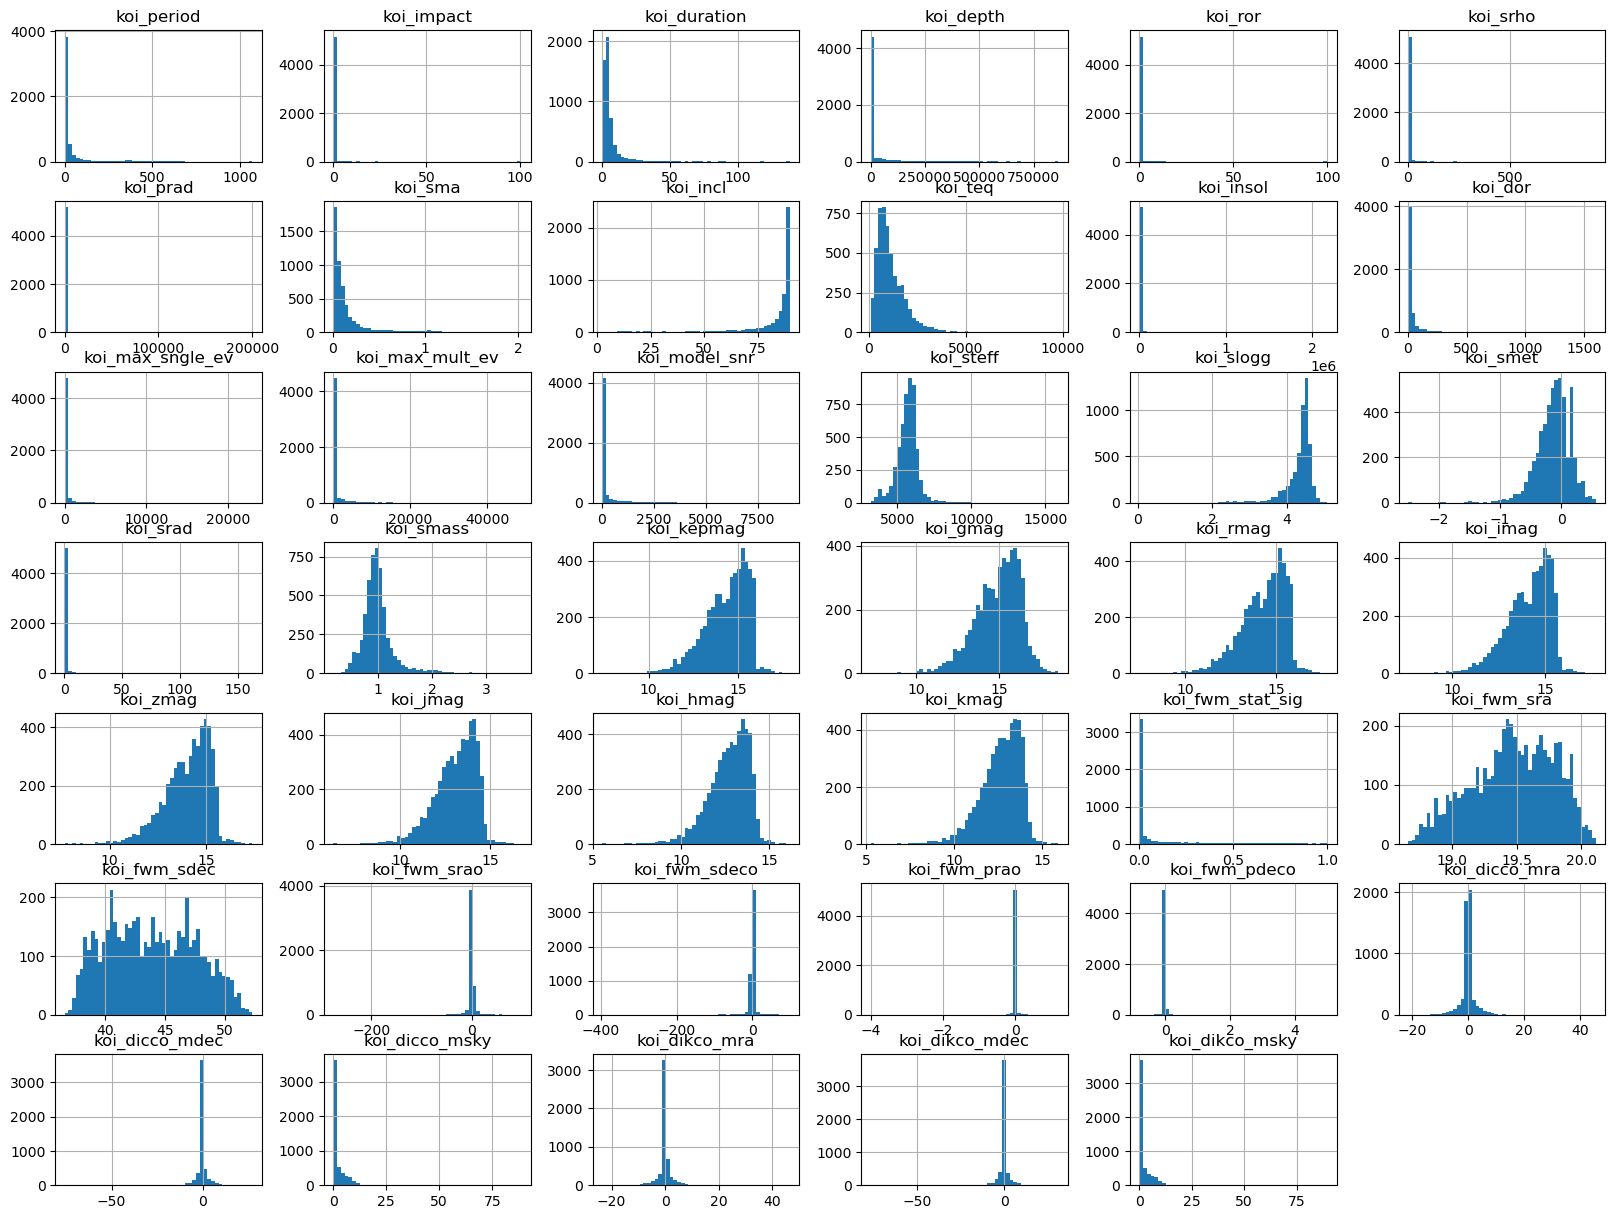

In [21]:
%matplotlib inline
df.hist(bins  = 50, figsize=(20,15))
plt.show()

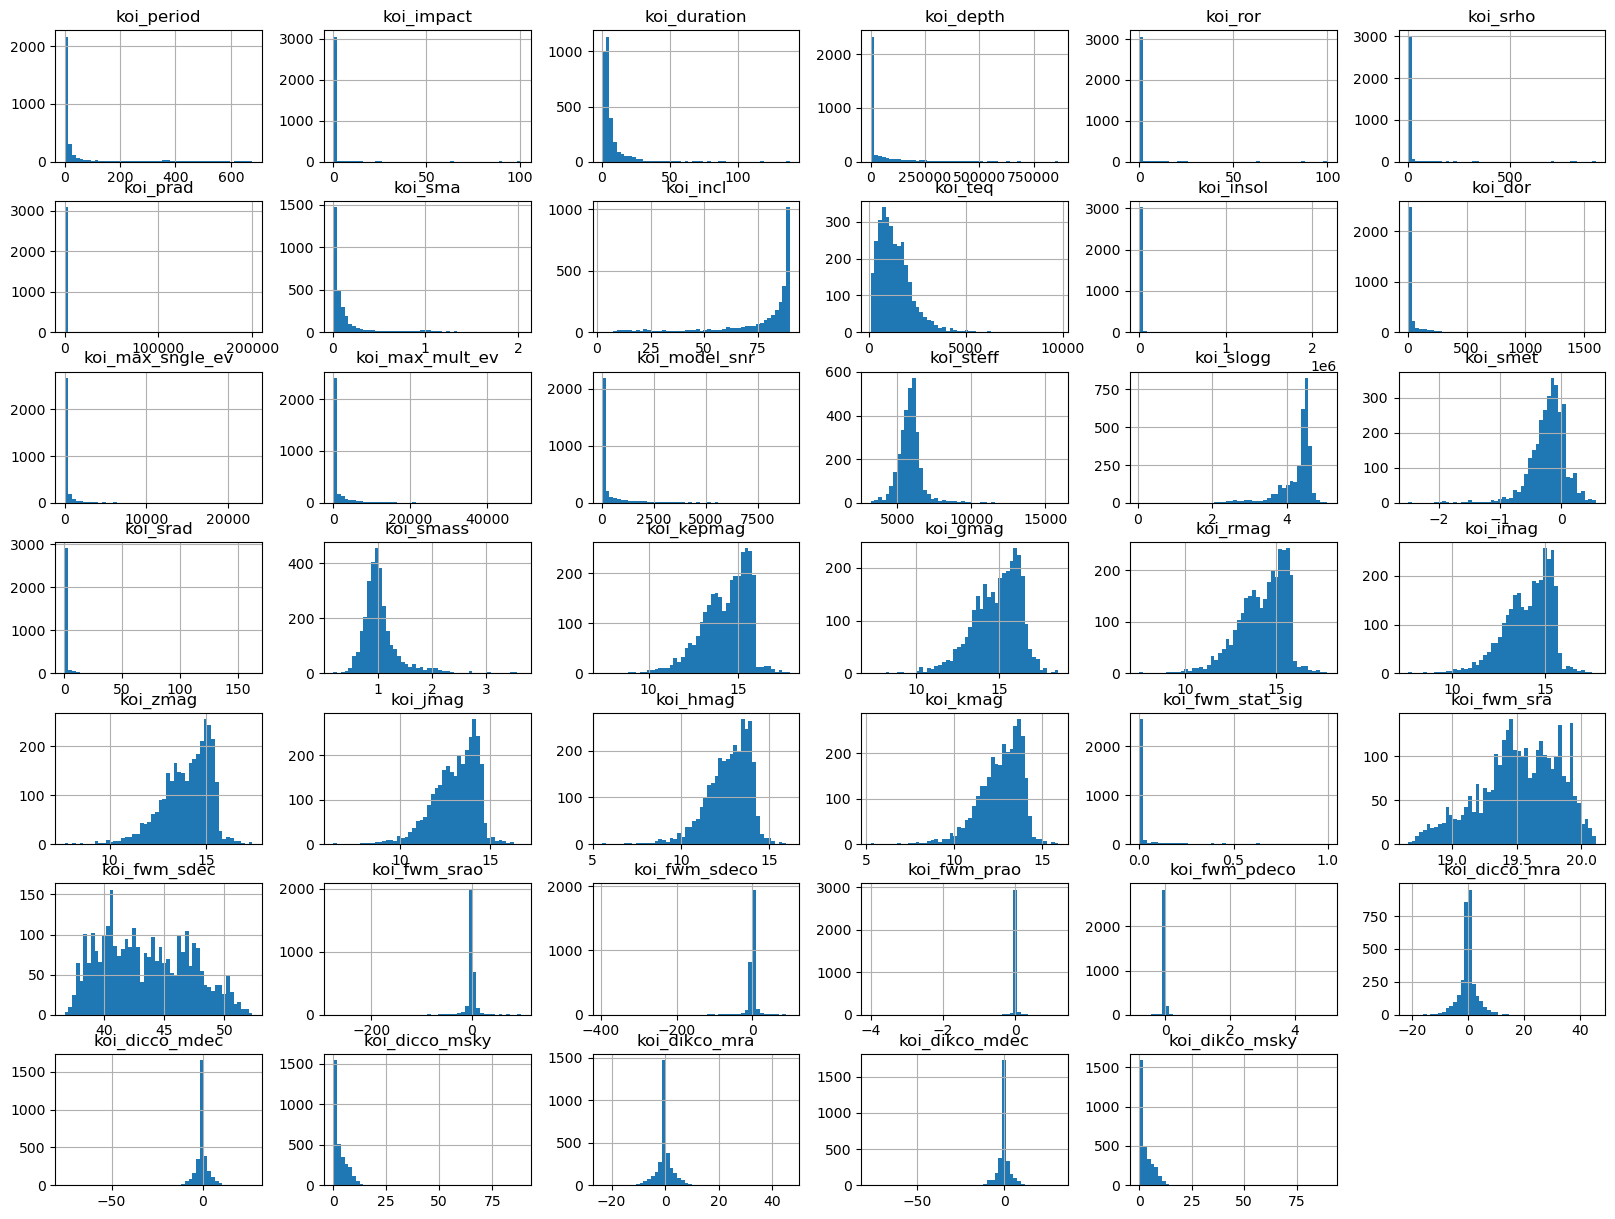

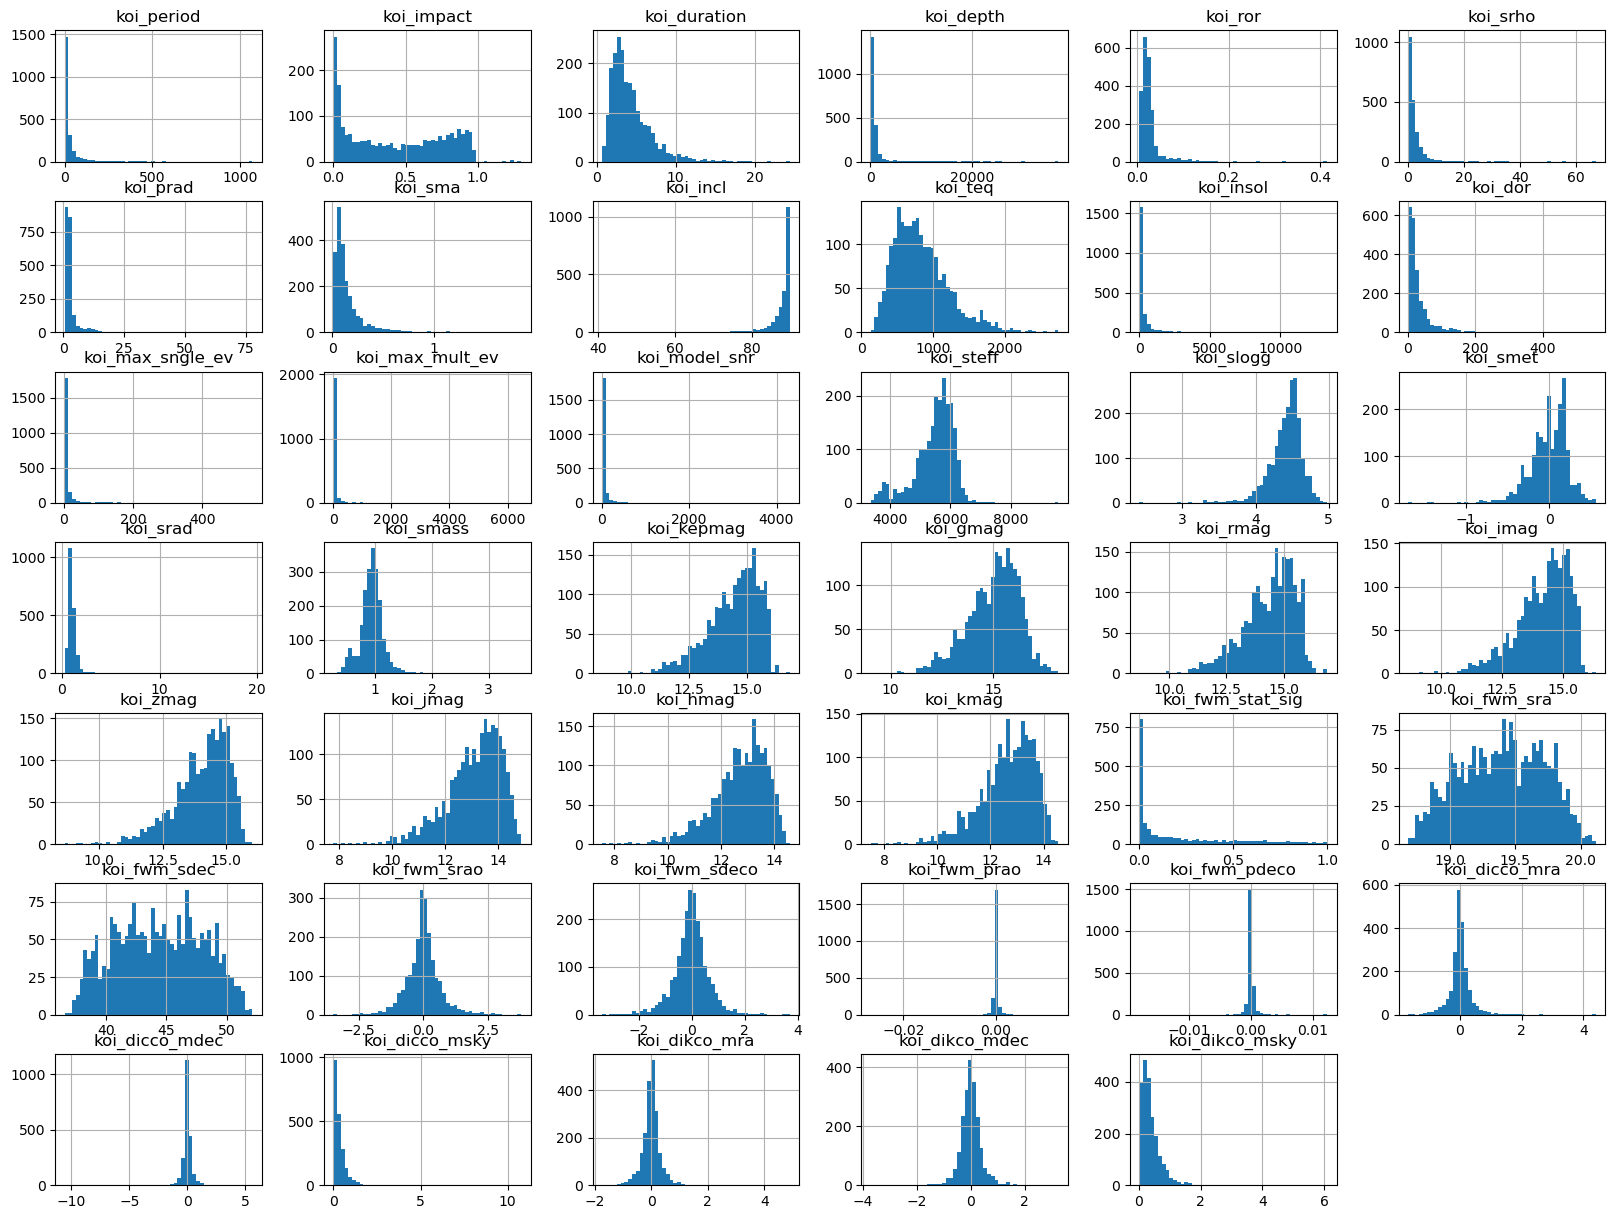

In [22]:
%matplotlib inline
df_false_positive.hist(bins  = 50, figsize=(20,15))
df_confirmed.hist(bins  = 50, figsize=(20,15))

plt.show()

### 2- Separação de X e Y(variavel alvo)


In [23]:

X = df.copy()
Y = X[['koi_disposition']]
X.drop(columns=['kepoi_name', 'koi_disposition'] , inplace=True)


### 3.  Normalização de Dados 

Para ter um melhor aproveitamento do modelo precisamos normalizar os dados 

Foi utilizado o metodo StandardScaler da biblioteca sklearn do modulo preprocessing 
Ele transforma os dados para que tenham média zero  e desvio padrão unitário, centrando os dados e colocando-os na mesma escala, o que é crucial para algoritmos sensíveis à magnitude dos valores

Foi utilizado dentro do Pipeline para o SVM e k-NN pois estes modelos são sensíveis à escala das features (baseados em distância/margem).

Como aprendemos a  acurácia pode ser enganosa se as classes estiverem desbalanceadas. No nosso caso, utilizamos o F1-Score e a Matriz de Confusão para garantir que o modelo não está apenas chutando a classe majoritária, mas sim distinguindo corretamente entre exoplanetas confirmados e falsos positivos."



In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, learning_curve, KFold
from sklearn.model_selection import LearningCurveDisplay, ShuffleSplit, GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.inspection import DecisionBoundaryDisplay, permutation_importance
from sklearn.base import clone
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=41)

kf = KFold(n_splits=5, shuffle=True, random_state=41)

target_name = ["Confirmado", "Falso Positivo"]

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision_macro',
    'recall': 'recall_macro',
    'f1': 'f1_macro'
}

def print_cross_validate(score):
    print("--- Cross Validação (5 Folds) ---")
    print(f"Acurácia : {np.mean(score['test_accuracy']):.4f} ± {np.std(score['test_accuracy']):.4f}")
    print(f"Precisão : {np.mean(score['test_precision']):.4f} ± {np.std(score['test_precision']):.4f}")
    print(f"Recall   : {np.mean(score['test_recall']):.4f} ± {np.std(score['test_recall']):.4f}")
    print(f"F1-score : {np.mean(score['test_f1']):.4f} ± {np.std(score['test_f1']):.4f}\n")     

def print_classification_report(y_test_real, y_predito):
    print("--- Relatório de Classificação no Teste ---")
    print(classification_report(y_test_real, y_predito, target_names=target_name))

def plot_matrix(y_test_real, y_predito):
    ConfusionMatrixDisplay.from_predictions(y_test_real, y_predito, display_labels=target_name, cmap=plt.cm.Blues)
    plt.title("Matriz de Confusão - Teste")
    plt.show()

def plot_curve(model):
    fig, ax = plt.subplots(figsize=(10, 6), sharey=True)
    common_params = {
        "X": X,
        "y": Y,
        "train_sizes": np.linspace(0.1, 1.0, 5),
        "cv": kf,
        "scoring": "f1_macro",
        "n_jobs": -1,
        "line_kw": {"marker": "o"},
        "std_display_style": "fill_between",
    }
    if hasattr(model, 'steps'):
        model_name = model.steps[-1][1].__class__.__name__
    else:
        model_name = model.__class__.__name__
        
    LearningCurveDisplay.from_estimator(model, **common_params, ax=ax)
    ax.set_title(f"Curva de Aprendizagem - {model_name}")
    ax.set_xlabel("Tamanho do conjunto de treino")
    ax.set_ylabel("F1-score (Macro)")
    ax.grid()
    plt.show()

def plot_features_importece(clf):
    if hasattr(clf, 'steps'):
        model = clf.steps[-1][1]
    else:
        model = clf
        
    if hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
        order = np.argsort(imp)[::1]
        plt.figure(figsize=(10, 8))
        plt.barh(np.array(X.columns)[order][::1], imp[order][::1])
        plt.title("Importância das Features")
        plt.tight_layout()
        plt.show()

def plot_decision_boundary(modelo_treinado, X_train_full, y_train_full, feature1, feature2):
    
    X_train_2d = X_train_full[[feature1, feature2]]

    modelo_2d = clone(modelo_treinado)
    modelo_2d.fit(X_train_2d, y_train_full)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    

    DecisionBoundaryDisplay.from_estimator(
        modelo_2d,
        X_train_2d,
        response_method="predict",
        cmap=plt.cm.RdBu,
        alpha=0.6,
        ax=ax
    )
    

    y_train_num = LabelEncoder().fit_transform(np.ravel(y_train_full))

    scatter = ax.scatter(
        X_train_2d[feature1], 
        X_train_2d[feature2], 
        c=y_train_num, 
        edgecolors="k", 
        cmap=plt.cm.RdBu
    )
    
    model_name = modelo_treinado.steps[-1][1].__class__.__name__ if hasattr(modelo_treinado, 'steps') else modelo_treinado.__class__.__name__
        
    plt.title(f"Fronteiras de Decisão: {model_name}")
    plt.xlabel(feature1)
    plt.ylabel(feature2)

def plot_roc_curve(model, X_test, y_test):
    from sklearn.metrics import RocCurveDisplay
    if hasattr(model, 'steps'):
        model_name = model.steps[-1][1].__class__.__name__
    else:
        model_name = model.__class__.__name__
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Gera a Curva ROC
    RocCurveDisplay.from_estimator(
        model, 
        X_test, 
        y_test, 
        ax=ax, 
        name=model_name,
        color='darkorange'
    )
    
    # Adiciona a linha de referência (classificador aleatório)
    ax.plot([0, 1], [0, 1], "k--", label="Aleatório (AUC = 0.5)")
    
    ax.set_title(f"Curva ROC - {model_name}")
    ax.set_xlabel("Taxa de Falsos Positivos (FPR)")
    ax.set_ylabel("Taxa de Verdadeiros Positivos (TPR)")
    ax.legend(loc="lower right")
    ax.grid(alpha=0.3)
    plt.show()

## Naive Bayes

Para que serve: Modelo probabilístico que assume independência entre os atributos. Serve como referência mínima de desempenho.

Melhores Features: koi_ror e koi_dikco_msky.

Resultados e Conclusão: * Acurácia CV: 91,62% | Acurácia Treino: 91,27%.

Análise: O modelo apresentou um desempenho surpreendentemente alto para um baseline. A proximidade entre a acurácia de treino e validação mostra que o modelo não sofre de overfitting, mas sua simplicidade pode limitar a captura de relações complexas entre os dados orbitais.

Tarefa: Atuou como base comparativa estável.

--- Cross Validação (5 Folds) ---
Acurácia : 0.9162 ± 0.0062
Precisão : 0.9116 ± 0.0066
Recall   : 0.9253 ± 0.0060
F1-score : 0.9147 ± 0.0064

--- Relatório de Classificação no Teste ---
                precision    recall  f1-score   support

    Confirmado       0.85      0.98      0.91       427
Falso Positivo       0.98      0.88      0.93       614

      accuracy                           0.92      1041
     macro avg       0.92      0.93      0.92      1041
  weighted avg       0.93      0.92      0.92      1041

Acurácia Treino: 0.912761355443403


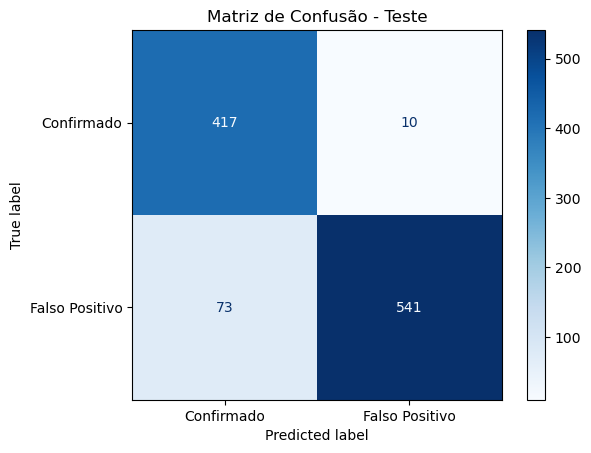

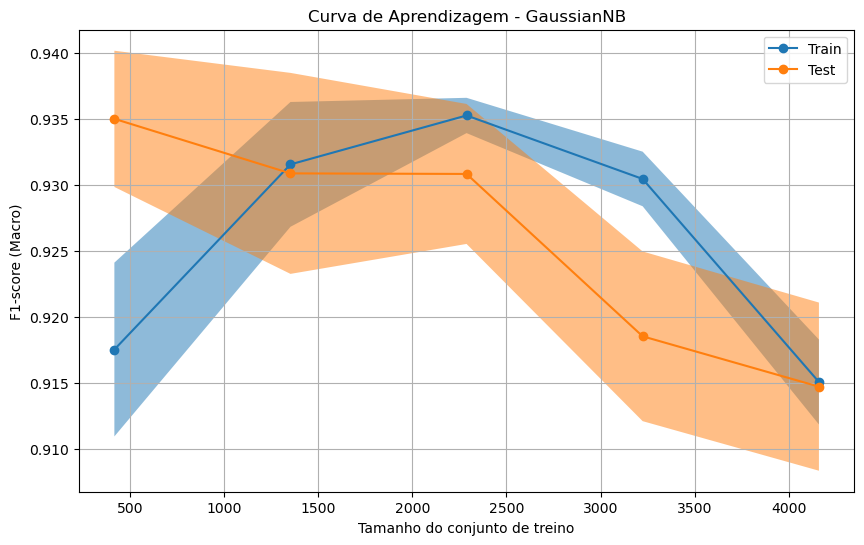


Melhores features (NB): 'koi_ror' e 'koi_dikco_msky'


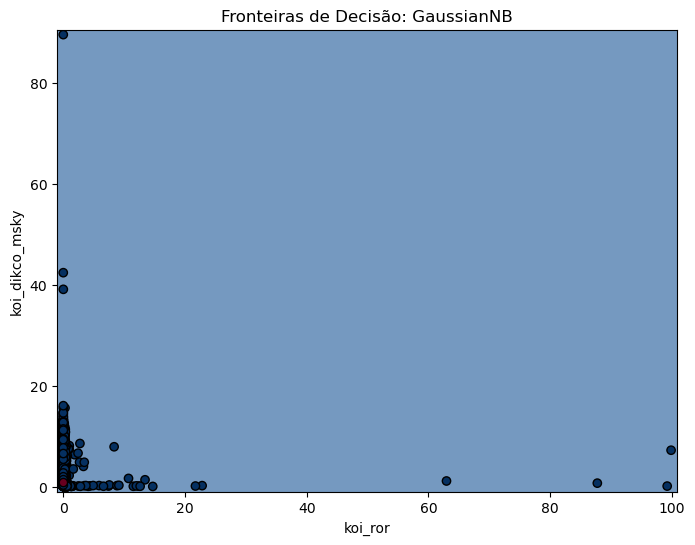

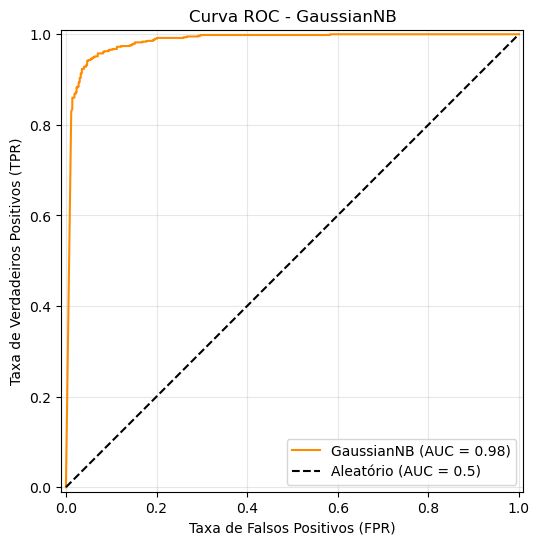

In [25]:
clf_nb = make_pipeline(StandardScaler(), GaussianNB())

score_nb = cross_validate(clf_nb, X, Y, cv=kf, scoring=scoring)
print_cross_validate(score_nb)

clf_nb.fit(X_train, y_train)
y_pred_nb = clf_nb.predict(X_test) 

print_classification_report(y_test, y_pred_nb)
print(f"Acurácia Treino: {clf_nb.score(X_train, y_train)}")

plot_matrix(y_test, y_pred_nb)
plot_curve(clf_nb)

resultado_imp_nb = permutation_importance(clf_nb, X_test, y_test, n_repeats=5, random_state=41, n_jobs=-1)
top_2_indices_nb = np.argsort(resultado_imp_nb.importances_mean)[-2:]
feature1_nb = X_train.columns[top_2_indices_nb[1]]
feature2_nb = X_train.columns[top_2_indices_nb[0]]

print(f"\nMelhores features (NB): '{feature1_nb}' e '{feature2_nb}'")
plot_decision_boundary(clf_nb, X_train, y_train, feature1_nb, feature2_nb)
plot_roc_curve(clf_nb, X_test, y_test)

## Arvore De Classificação

Para que serve: Classifica através de divisões hierárquicas dos dados. O foco foi o ajuste da profundidade.

Parâmetros/Features: max_depth: 10, min_samples_split: 10. Features: koi_fwm_stat_sig e koi_prad.

Resultados e Conclusão:

Acurácia CV: 94,91% | Acurácia Treino: 98,67%.

Análise: Com profundidade 10, o modelo superou o baseline. No entanto, a diferença entre o treino (98,6%) e a validação (94,9%) indica um leve overfitting. A árvore começou a se ajustar demais às especificidades da base de treino.

Tarefa: Demonstrou como a profundidade controla a complexidade do modelo.

OBS: Com max_depth=10, encontramos um equilíbrio. Se fosse ilimitada, teríamos baixa tendência (bias) mas alta variância (overfitting), como visto no score de 100% no treino

Melhores parâmetros encontrados: {'max_depth': 10, 'min_samples_split': 10}
--- Cross Validação (5 Folds) ---
Acurácia : 0.9491 ± 0.0077
Precisão : 0.9455 ± 0.0080
Recall   : 0.9496 ± 0.0077
F1-score : 0.9474 ± 0.0078

--- Relatório de Classificação no Teste ---
                precision    recall  f1-score   support

    Confirmado       0.93      0.95      0.94       427
Falso Positivo       0.96      0.95      0.96       614

      accuracy                           0.95      1041
     macro avg       0.95      0.95      0.95      1041
  weighted avg       0.95      0.95      0.95      1041

Acurácia Treino: 0.9867820235520307


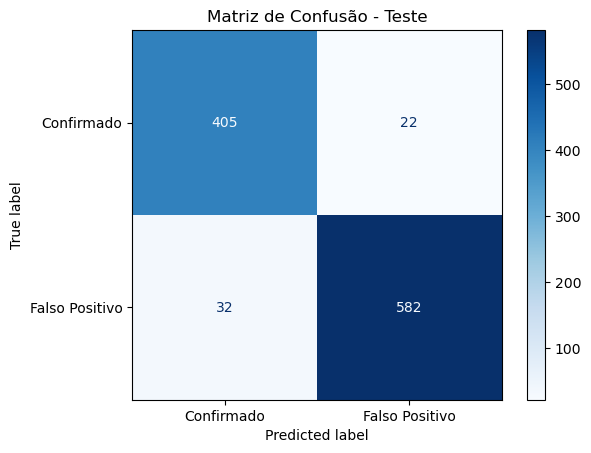

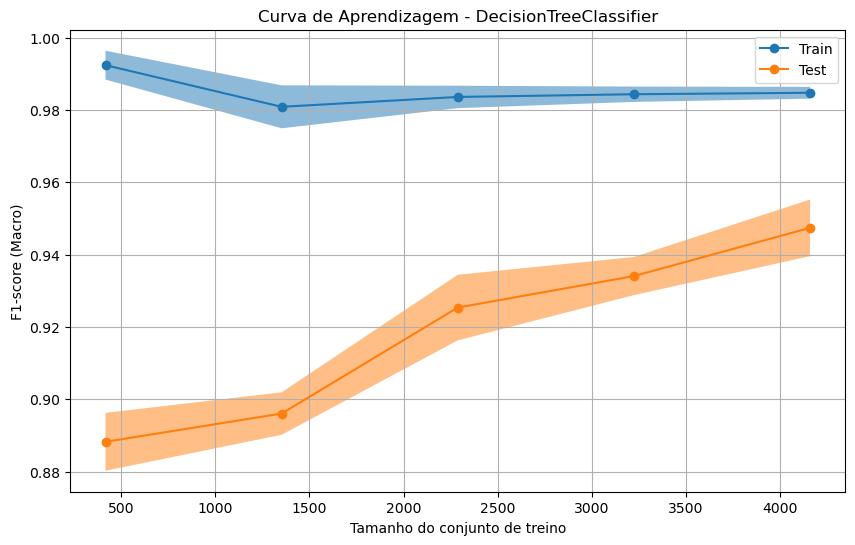

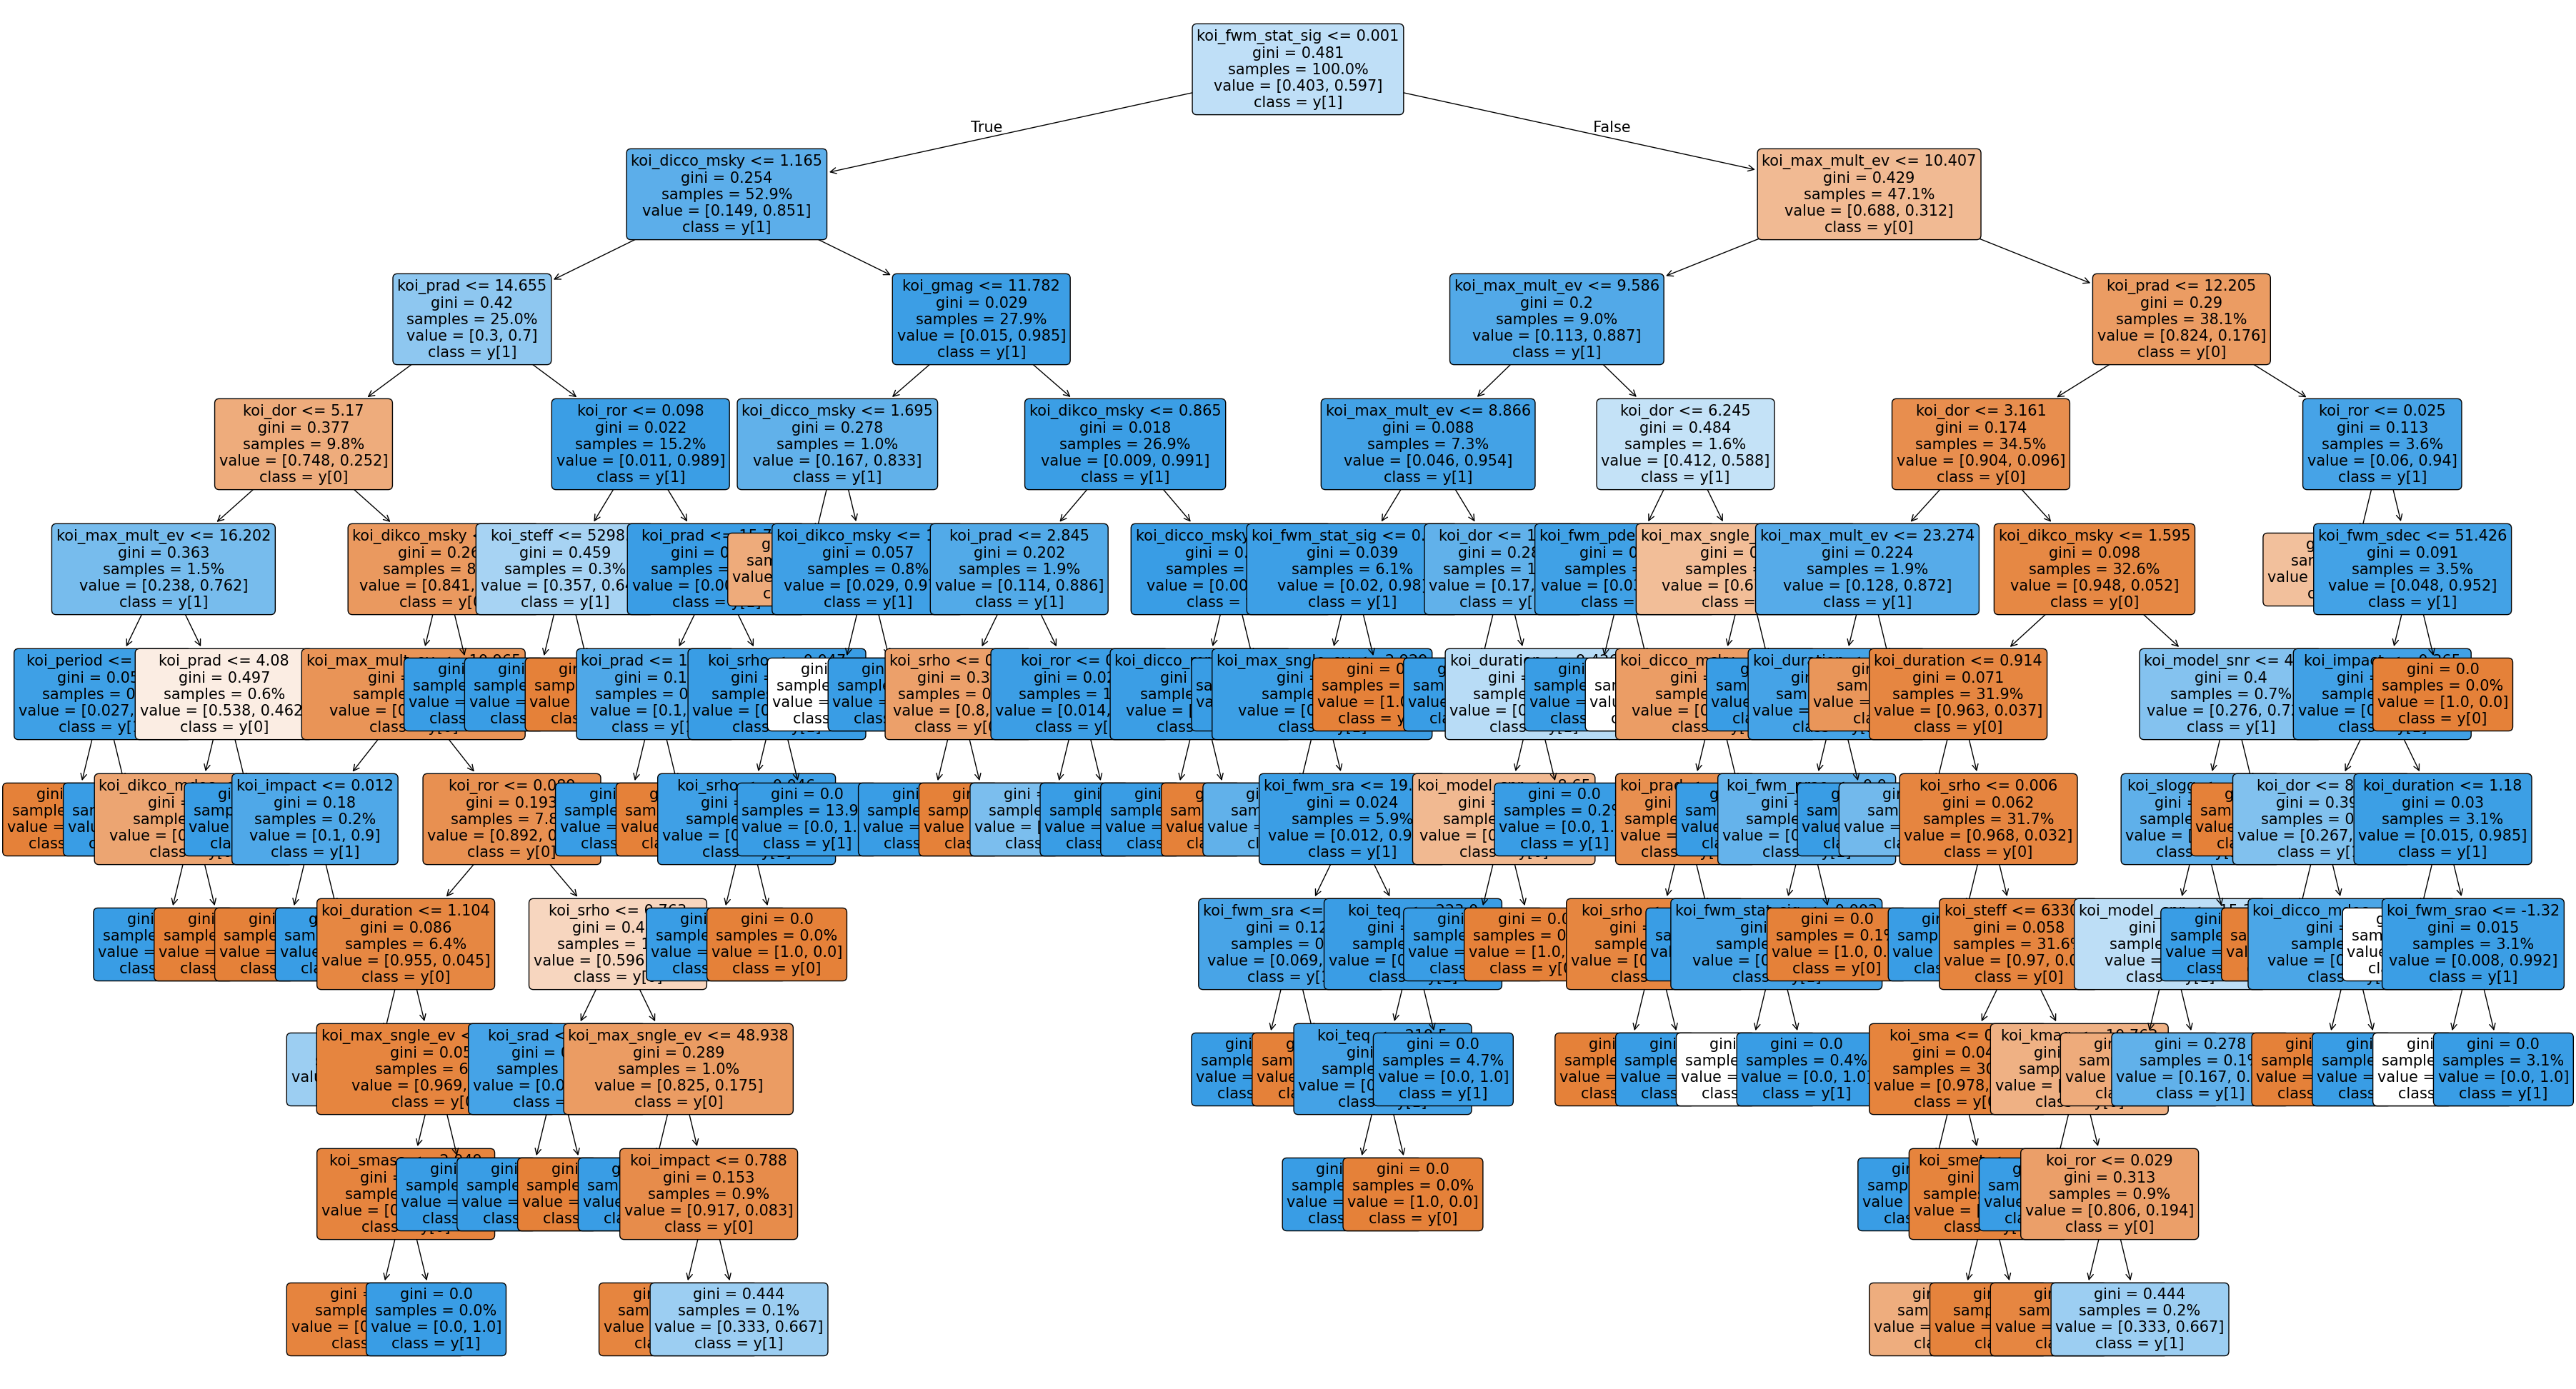

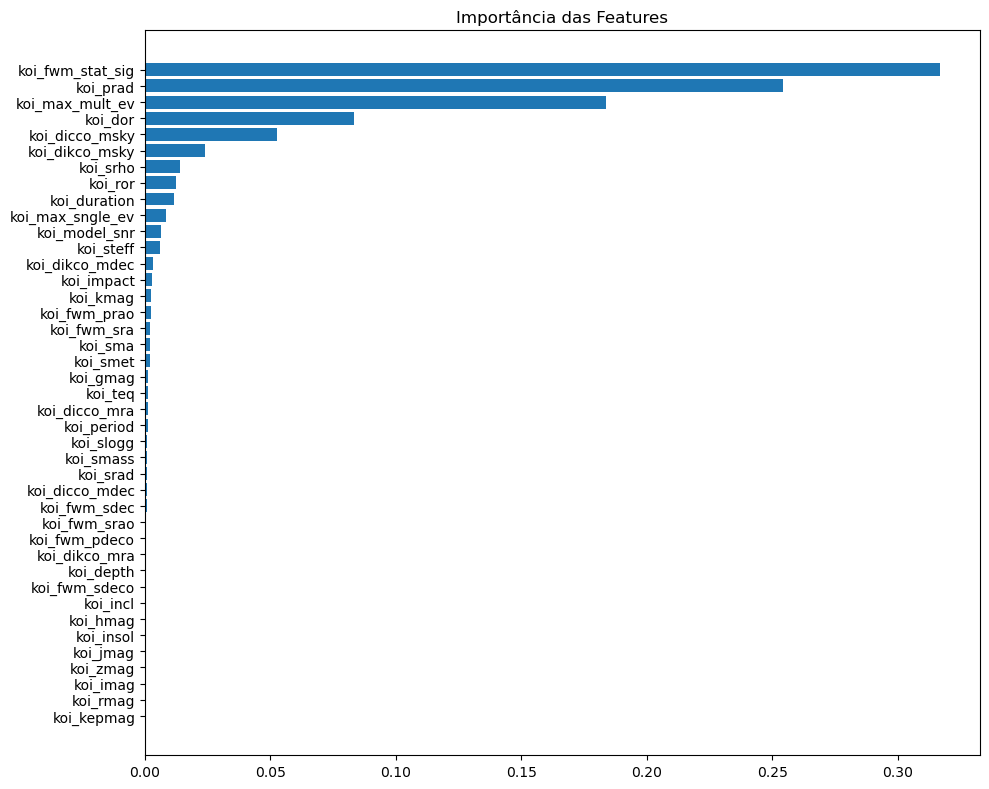


Melhores features (DT): 'koi_fwm_stat_sig' e 'koi_prad'


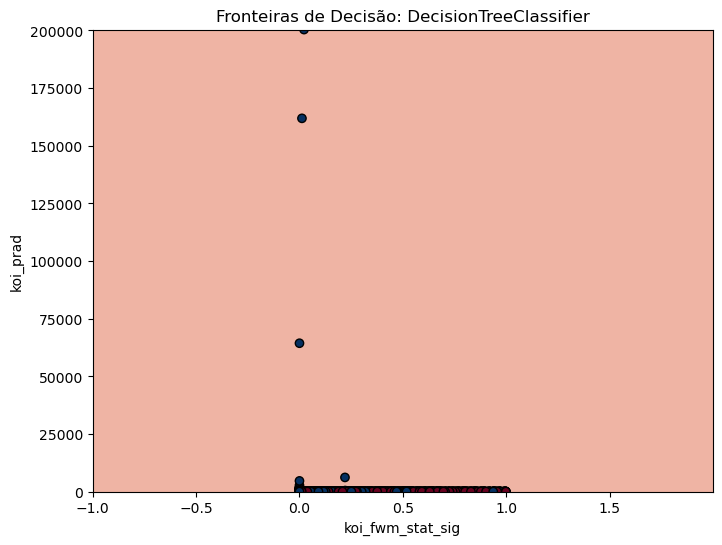

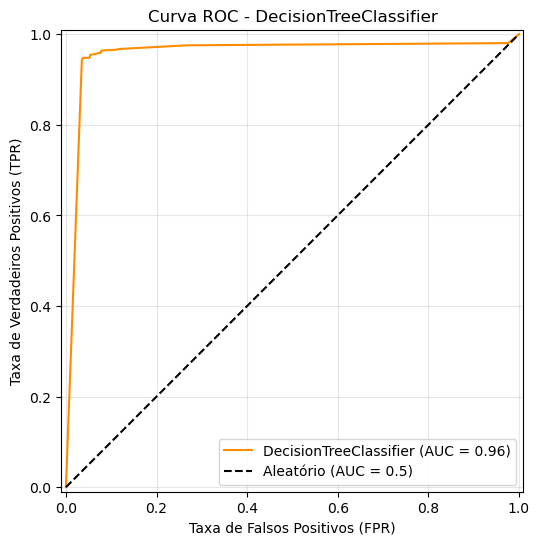

In [26]:
clf_dt = DecisionTreeClassifier(random_state=41)

parametros_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid_dt = GridSearchCV(clf_dt, parametros_dt, cv=kf, scoring='f1_macro', n_jobs=-1)
grid_dt.fit(X_train, y_train)

print(f"Melhores parâmetros encontrados: {grid_dt.best_params_}")

melhor_clf_dt = grid_dt.best_estimator_

score_dt = cross_validate(melhor_clf_dt, X, Y, cv=kf, scoring=scoring)
print_cross_validate(score_dt)

y_pred_dt = melhor_clf_dt.predict(X_test)

print_classification_report(y_test, y_pred_dt)
print(f"Acurácia Treino: {melhor_clf_dt.score(X_train, y_train)}")

plot_matrix(y_test, y_pred_dt)
plot_curve(melhor_clf_dt)

plt.figure(figsize=(45,25))
tree.plot_tree(melhor_clf_dt, proportion=True, fontsize=15, feature_names=X.columns , filled=True, class_names=True, rounded=True)
plt.show()

plot_features_importece(melhor_clf_dt)

importancias_dt = melhor_clf_dt.feature_importances_
top_2_indices_dt = np.argsort(importancias_dt)[-2:]
feature1_dt = X.columns[top_2_indices_dt[1]]
feature2_dt = X.columns[top_2_indices_dt[0]]

print(f"\nMelhores features (DT): '{feature1_dt}' e '{feature2_dt}'")
plot_decision_boundary(melhor_clf_dt, X_train, y_train, feature1_dt, feature2_dt)
plot_roc_curve(melhor_clf_dt, X_test, y_test)

## k-Nearest Neighbors (k-NN)
Para que serve: Classifica por similaridade (proximidade) entre instâncias.

Parâmetros/Features: k: 3, weights: uniform. 

Features: koi_incl e koi_teq.

Resultados e Conclusão:Acurácia CV: 89,39% | Acurácia Treino: 93,29%.Análise: 

Foi o modelo com o desempenho mais baixo entre os testados. O valor de k=3 sugere que o modelo precisa de fronteiras locais muito específicas, o que o torna sensível a ruídos nos dados dos exoplanetas.

Tarefa: Ilustrou a sensibilidade do modelo à escolha da métrica de distância e número de vizinhos.

OBS: Um k muito pequeno (ex: 1) aumenta a variância e torna o modelo sensível a ruído. O valor escolhido buscou estabilizar a fronteira de decisão.

Melhores parâmetros k-NN: {'knn__n_neighbors': 3, 'knn__weights': 'uniform'}
--- Cross Validação (5 Folds) ---
Acurácia : 0.8939 ± 0.0085
Precisão : 0.8903 ± 0.0077
Recall   : 0.9040 ± 0.0071
F1-score : 0.8923 ± 0.0084

--- Relatório de Classificação no Teste ---
                precision    recall  f1-score   support

    Confirmado       0.84      0.95      0.89       427
Falso Positivo       0.96      0.87      0.91       614

      accuracy                           0.90      1041
     macro avg       0.90      0.91      0.90      1041
  weighted avg       0.91      0.90      0.90      1041

Acurácia Treino: 0.9329488103821196


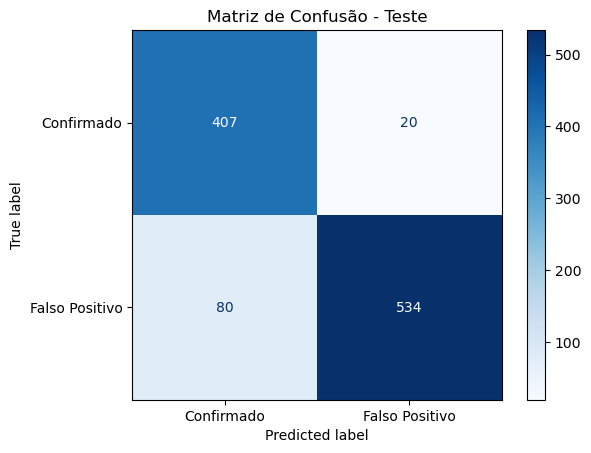

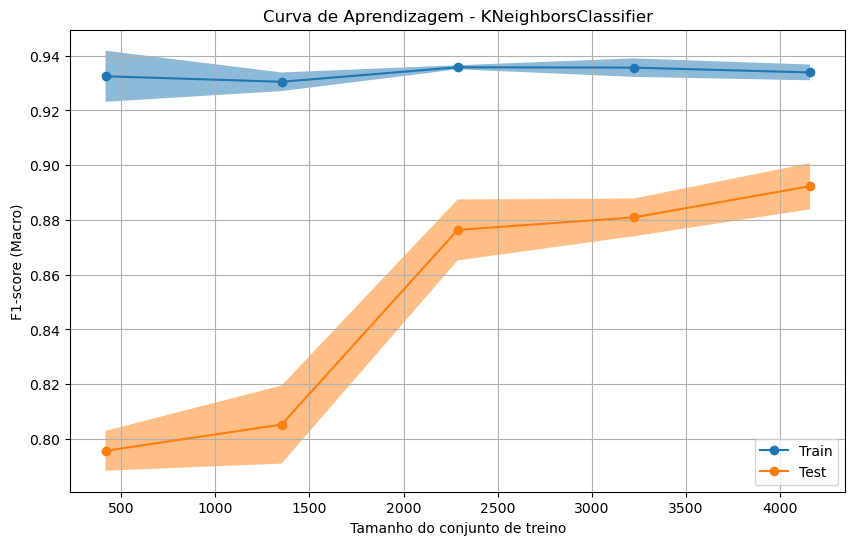


Melhores features (k-NN): 'koi_incl' e 'koi_teq'


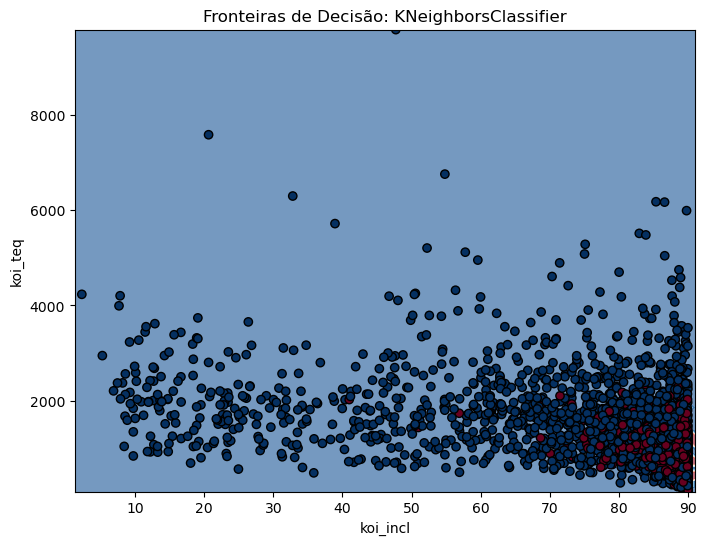

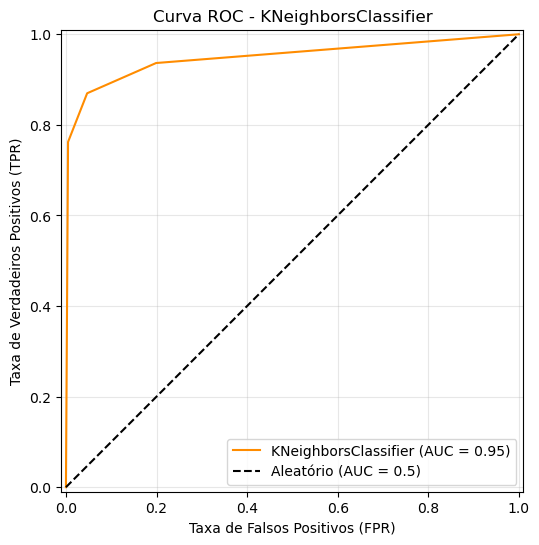

In [27]:
pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

parametros_knn = {
    'knn__n_neighbors': [3, 5, 7, 11, 15],
    'knn__weights': ['uniform', 'distance']
}

grid_knn = GridSearchCV(pipeline_knn, parametros_knn, cv=kf, scoring='f1_macro', n_jobs=-1)
grid_knn.fit(X_train, y_train)

print(f"Melhores parâmetros k-NN: {grid_knn.best_params_}")

melhor_knn = grid_knn.best_estimator_

score_knn = cross_validate(melhor_knn, X, Y, cv=kf, scoring=scoring)
print_cross_validate(score_knn)

y_pred_knn = melhor_knn.predict(X_test)

print_classification_report(y_test, y_pred_knn)
print(f"Acurácia Treino: {melhor_knn.score(X_train, y_train)}")

plot_matrix(y_test, y_pred_knn)
plot_curve(melhor_knn)

resultado_imp_knn = permutation_importance(melhor_knn, X_test, y_test, n_repeats=5, random_state=41, n_jobs=-1)
top_2_indices_knn = np.argsort(resultado_imp_knn.importances_mean)[-2:]
feature1_knn = X_train.columns[top_2_indices_knn[1]]
feature2_knn = X_train.columns[top_2_indices_knn[0]]

print(f"\nMelhores features (k-NN): '{feature1_knn}' e '{feature2_knn}'")
plot_decision_boundary(melhor_knn, X_train, y_train, feature1_knn, feature2_knn)
plot_roc_curve(melhor_knn, X_test, y_test)

## Support Vector Machines (SVM)

Para que serve: Encontra o hiperplano de separação máxima entre as classes.

Parâmetros/Features: C: 10, kernel: linear. Features: koi_zmag e koi_dikco_msky.

Resultados e Conclusão:Acurácia CV: 95,44% | Acurácia Treino: 95,89%.Análise: Excelente estabilidade. O kernel linear com $C=10$ (margem mais rígida) funcionou muito bem, com resultados de treino e validação quase idênticos, sugerindo uma ótima capacidade de generalização.

Tarefa: Provou que os dados podem ser bem separados linearmente em certas projeções.

Melhores parâmetros SVM: {'svm__C': 10, 'svm__kernel': 'linear'}
--- Cross Validação (5 Folds) ---
Acurácia : 0.9544 ± 0.0033
Precisão : 0.9513 ± 0.0033
Recall   : 0.9548 ± 0.0040
F1-score : 0.9529 ± 0.0035

--- Relatório de Classificação no Teste ---
                precision    recall  f1-score   support

    Confirmado       0.94      0.96      0.95       427
Falso Positivo       0.97      0.96      0.96       614

      accuracy                           0.96      1041
     macro avg       0.95      0.96      0.95      1041
  weighted avg       0.96      0.96      0.96      1041

Acurácia Treino: 0.958904109589041


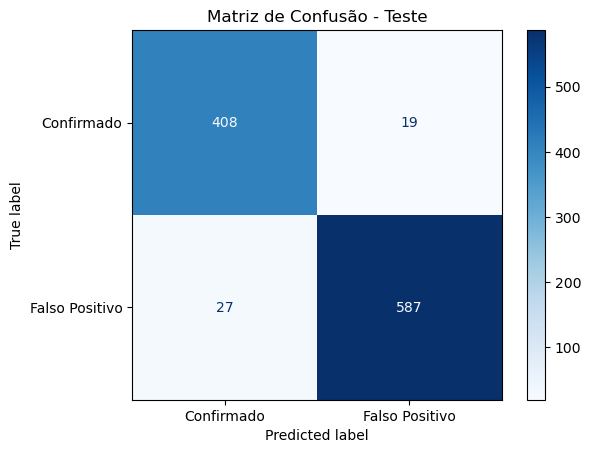

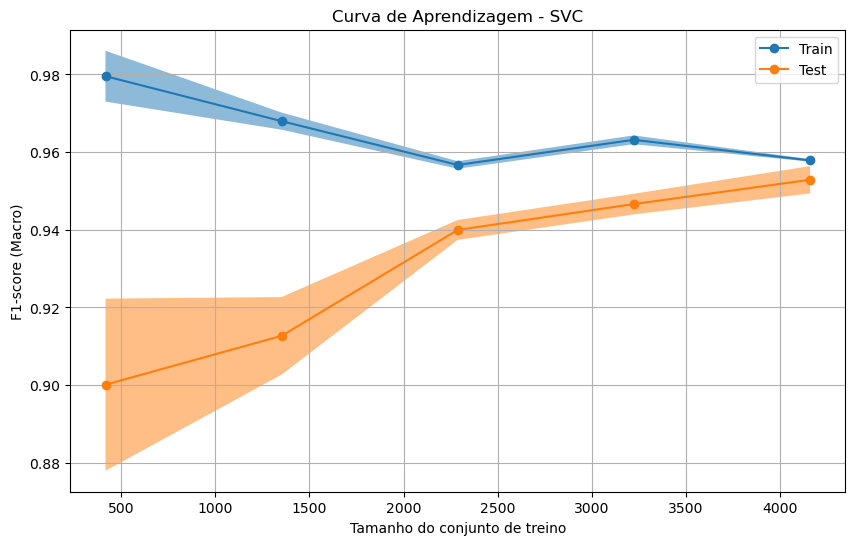


Melhores features (SVM): 'koi_zmag' e 'koi_dikco_msky'


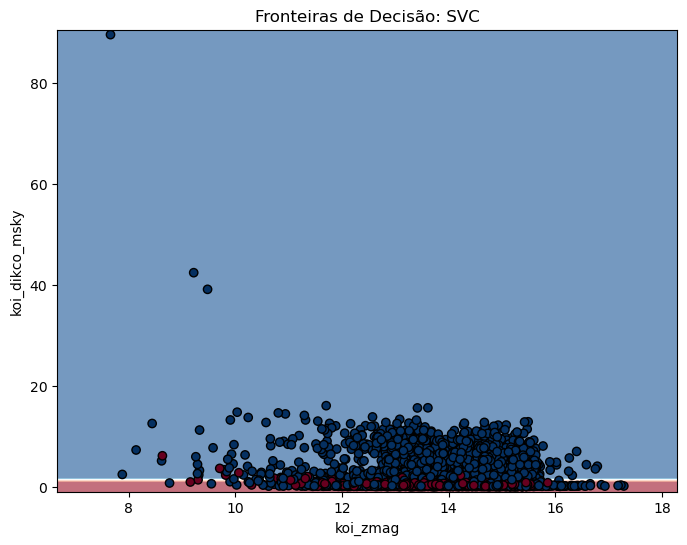

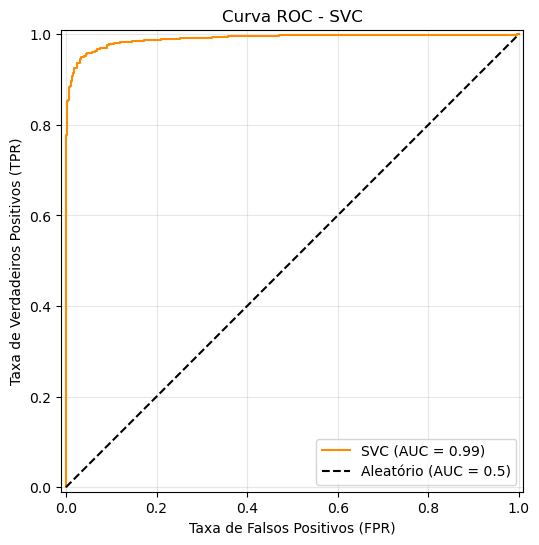

In [28]:
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=41))
])

parametros_svm = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf']
}

grid_svm = GridSearchCV(pipeline_svm, parametros_svm, cv=kf, scoring='f1_macro', n_jobs=-1)
grid_svm.fit(X_train, y_train)

print(f"Melhores parâmetros SVM: {grid_svm.best_params_}")

melhor_svm = grid_svm.best_estimator_

score_svm = cross_validate(melhor_svm, X, Y, cv=kf, scoring=scoring)
print_cross_validate(score_svm)

y_pred_svm = melhor_svm.predict(X_test)

print_classification_report(y_test, y_pred_svm)
print(f"Acurácia Treino: {melhor_svm.score(X_train, y_train)}")

plot_matrix(y_test, y_pred_svm)
plot_curve(melhor_svm)

resultado_imp_svm = permutation_importance(melhor_svm, X_test, y_test, n_repeats=5, random_state=41, n_jobs=-1)
top_2_indices_svm = np.argsort(resultado_imp_svm.importances_mean)[-2:]
feature1_svm = X_train.columns[top_2_indices_svm[1]]
feature2_svm = X_train.columns[top_2_indices_svm[0]]

print(f"\nMelhores features (SVM): '{feature1_svm}' e '{feature2_svm}'")
plot_decision_boundary(melhor_svm, X_train, y_train, feature1_svm, feature2_svm)
plot_roc_curve(melhor_svm, X_test, y_test)

## Random Forest

Para que serve: Conjunto de árvores independentes (Bagging) para reduzir a variância.

Parâmetros/Features: n_estimators: 100, max_depth: None. Features: koi_dicco_msky e koi_dikco_msky.

Resultados e Conclusão:

Acurácia CV: 96,96% | Acurácia Treino: 100%.

Análise: Alcançou acurácia perfeita no treino, o que é comum em RF com profundidade ilimitada. Contudo, a acurácia de 96,9% na validação mostra que a técnica de "votação" das 100 árvores mitigou o overfitting individual de cada árvore.

Tarefa: Demonstrou alta estabilidade e robustez.

Melhores parâmetros Random Forest: {'max_depth': None, 'n_estimators': 100}
--- Cross Validação (5 Folds) ---
Acurácia : 0.9696 ± 0.0070
Precisão : 0.9685 ± 0.0074
Recall   : 0.9685 ± 0.0073
F1-score : 0.9685 ± 0.0073

--- Relatório de Classificação no Teste ---
                precision    recall  f1-score   support

    Confirmado       0.98      0.96      0.97       427
Falso Positivo       0.97      0.98      0.98       614

      accuracy                           0.97      1041
     macro avg       0.97      0.97      0.97      1041
  weighted avg       0.97      0.97      0.97      1041

Acurácia Treino: 1.0


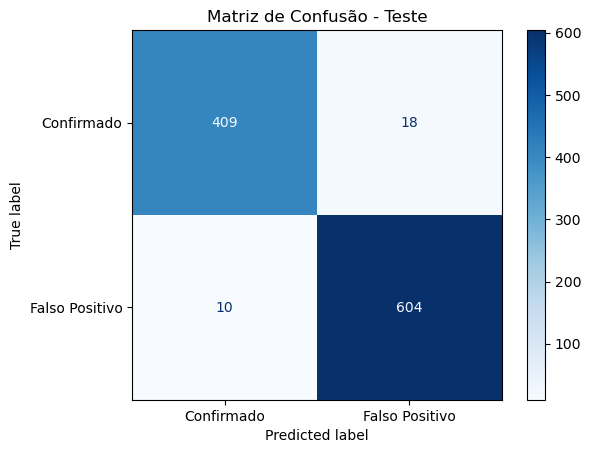

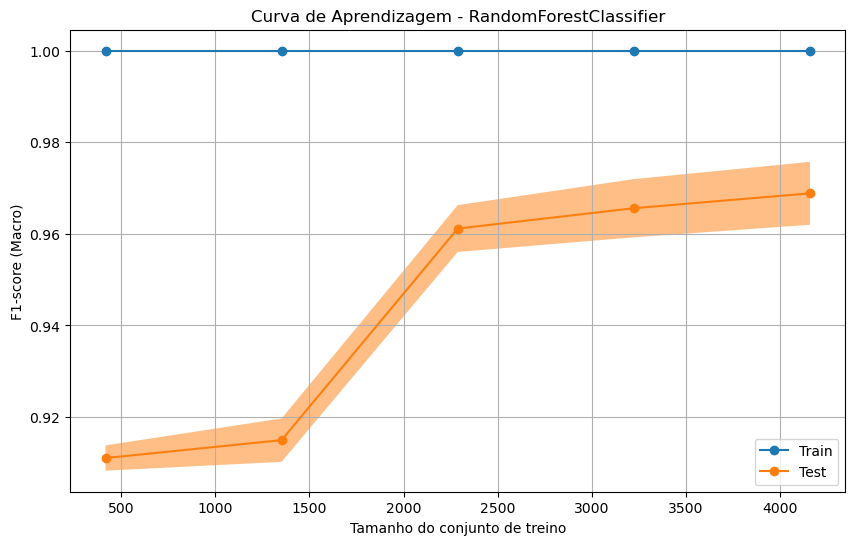

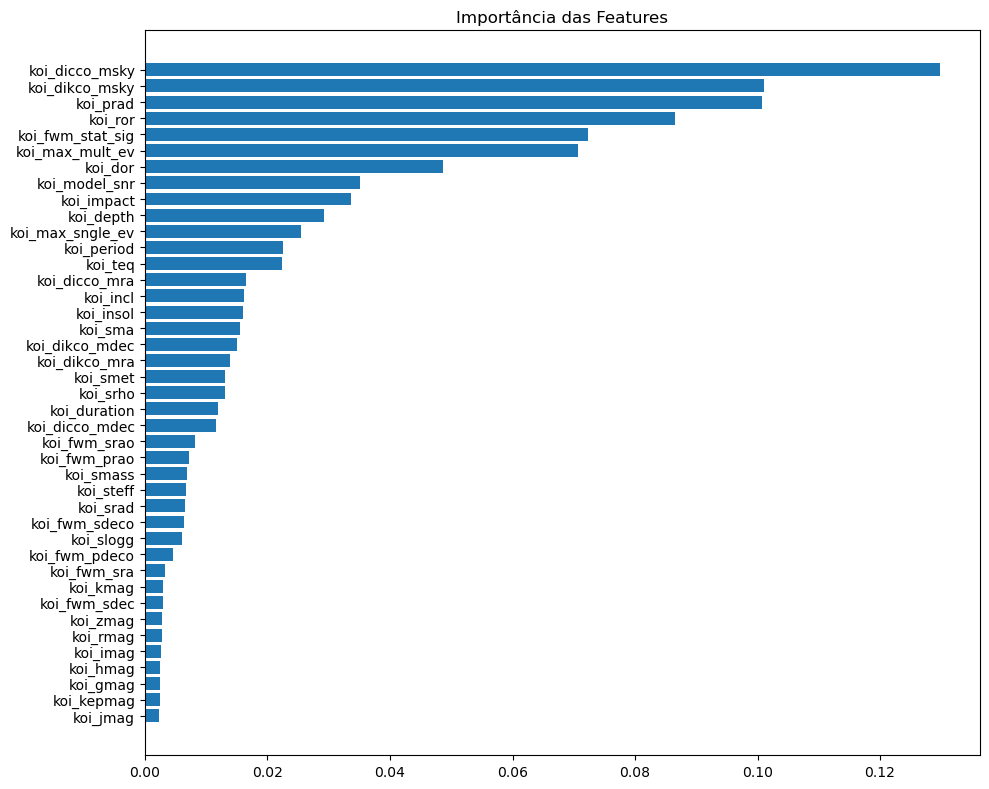


Melhores features (RF): 'koi_dicco_msky' e 'koi_dikco_msky'


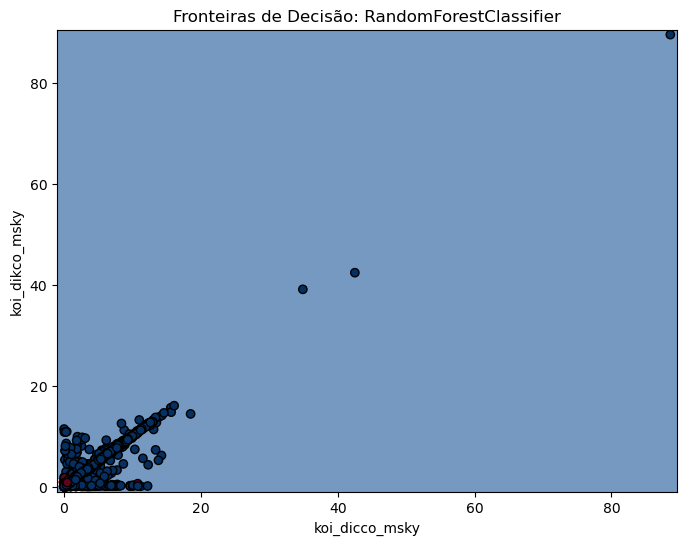

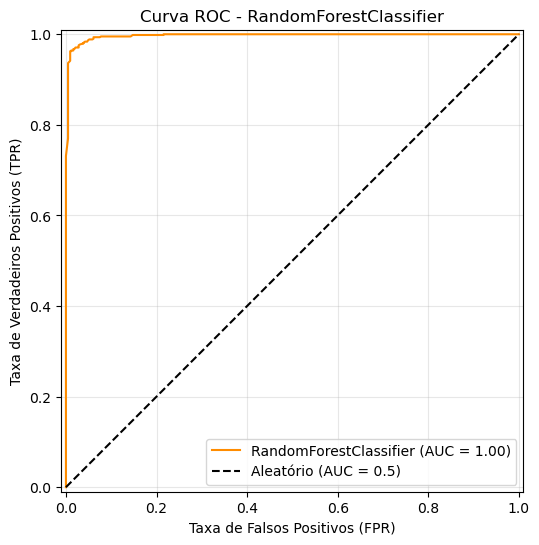

In [29]:
clf_rf = RandomForestClassifier(random_state=41)

parametros_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None]
}

grid_rf = GridSearchCV(clf_rf, parametros_rf, cv=kf, scoring='f1_macro', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print(f"Melhores parâmetros Random Forest: {grid_rf.best_params_}")

melhor_rf = grid_rf.best_estimator_

score_rf = cross_validate(melhor_rf, X, Y, cv=kf, scoring=scoring)
print_cross_validate(score_rf)

y_pred_rf = melhor_rf.predict(X_test)

print_classification_report(y_test, y_pred_rf)
print(f"Acurácia Treino: {melhor_rf.score(X_train, y_train)}")

plot_matrix(y_test, y_pred_rf)
plot_curve(melhor_rf)

plot_features_importece(melhor_rf)

importancias_rf = melhor_rf.feature_importances_
top_2_indices_rf = np.argsort(importancias_rf)[-2:]
feature1_rf = X.columns[top_2_indices_rf[1]]
feature2_rf = X.columns[top_2_indices_rf[0]]

print(f"\nMelhores features (RF): '{feature1_rf}' e '{feature2_rf}'")
plot_decision_boundary(melhor_rf, X_train, y_train, feature1_rf, feature2_rf)
plot_roc_curve(melhor_rf, X_test, y_test)

## Gradient Tree Boosting

Para que serve: Constrói árvores sequencialmente para corrigir erros das anteriores (Boosting).

Parâmetros/Features: learning_rate: 0.2, n_estimators: 100, max_depth: 5. Features: koi_prad e koi_fwm_stat_sig.

Resultados e Conclusão:

Acurácia CV: 97,39% | Acurácia Treino: 100%.

Análise: Melhor modelo do experimento. Obteve o maior F1-score médio (97,29%) e a melhor precisão no teste para falsos positivos (0.98). É o modelo mais eficaz para identificar exoplanetas reais com o mínimo de erro.

Tarefa: Exemplificou o maior poder preditivo através da correção iterativa de erros

Melhores parâmetros Gradient Boosting: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100}
--- Cross Validação (5 Folds) ---
Acurácia : 0.9739 ± 0.0041
Precisão : 0.9721 ± 0.0047
Recall   : 0.9737 ± 0.0040
F1-score : 0.9729 ± 0.0043

--- Relatório de Classificação no Teste ---
                precision    recall  f1-score   support

    Confirmado       0.98      0.97      0.98       427
Falso Positivo       0.98      0.99      0.98       614

      accuracy                           0.98      1041
     macro avg       0.98      0.98      0.98      1041
  weighted avg       0.98      0.98      0.98      1041

Acurácia Treino: 1.0


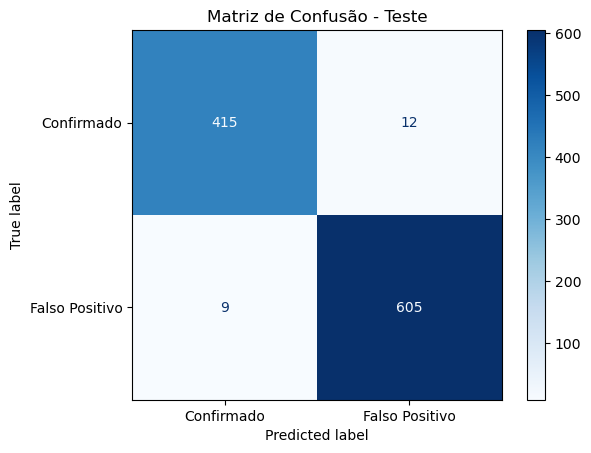

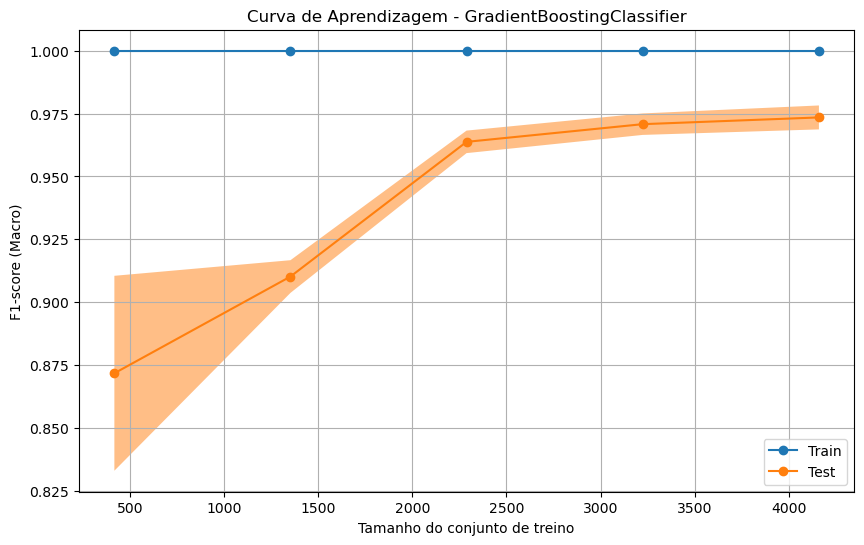

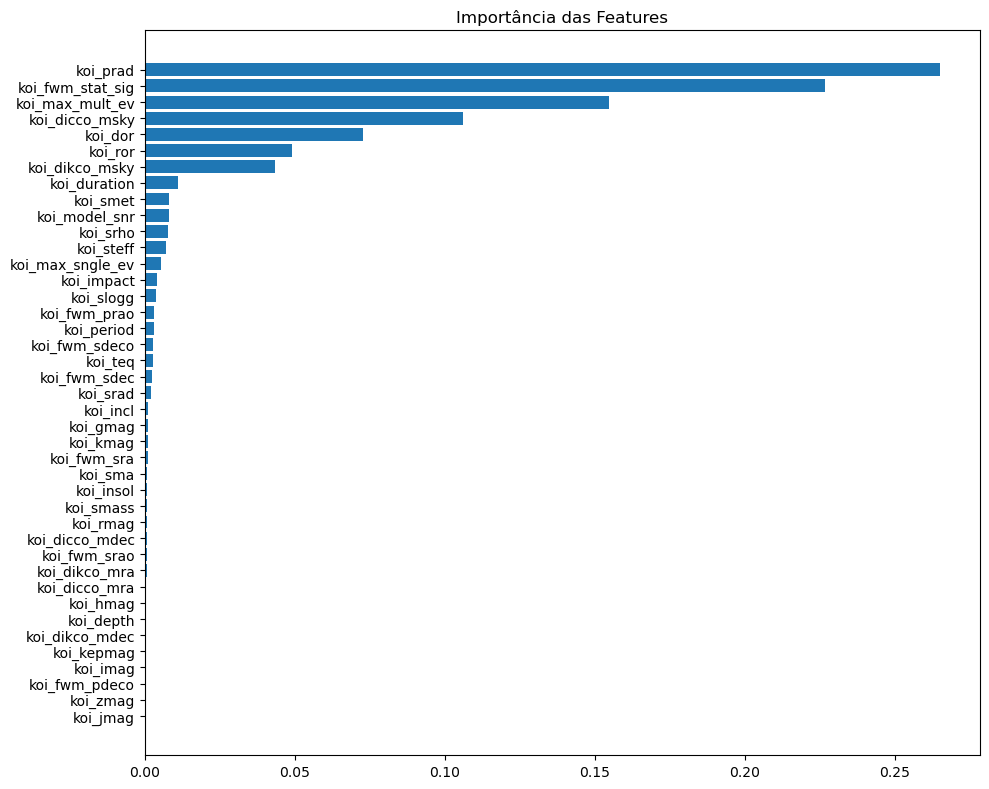


Melhores features (GB): 'koi_prad' e 'koi_fwm_stat_sig'


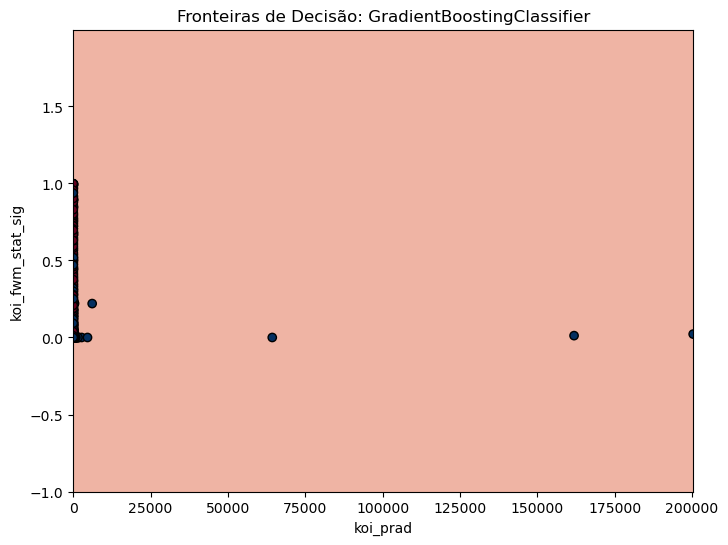

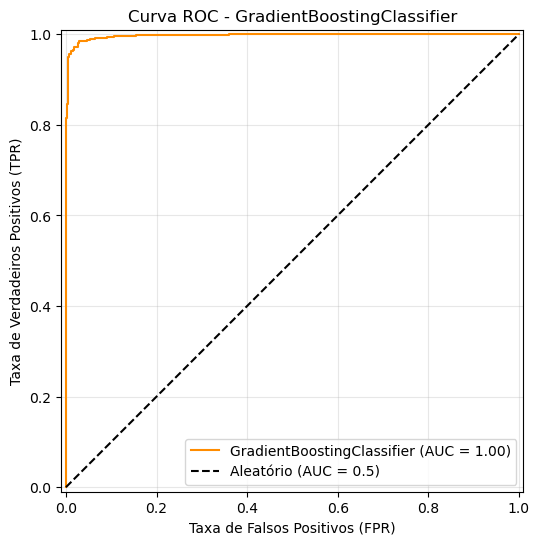

In [30]:
clf_gb = GradientBoostingClassifier(random_state=41)

parametros_gb = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5]
}

grid_gb = GridSearchCV(clf_gb, parametros_gb, cv=kf, scoring='f1_macro', n_jobs=-1)
grid_gb.fit(X_train, y_train)

print(f"Melhores parâmetros Gradient Boosting: {grid_gb.best_params_}")

melhor_gb = grid_gb.best_estimator_

score_gb = cross_validate(melhor_gb, X, Y, cv=kf, scoring=scoring)
print_cross_validate(score_gb)

y_pred_gb = melhor_gb.predict(X_test)

print_classification_report(y_test, y_pred_gb)
print(f"Acurácia Treino: {melhor_gb.score(X_train, y_train)}")

plot_matrix(y_test, y_pred_gb)
plot_curve(melhor_gb)

plot_features_importece(melhor_gb)

importancias_gb = melhor_gb.feature_importances_
top_2_indices_gb = np.argsort(importancias_gb)[-2:]
feature1_gb = X.columns[top_2_indices_gb[1]]
feature2_gb = X.columns[top_2_indices_gb[0]]

print(f"\nMelhores features (GB): '{feature1_gb}' e '{feature2_gb}'")
plot_decision_boundary(melhor_gb, X_train, y_train, feature1_gb, feature2_gb)
plot_roc_curve(melhor_gb, X_test, y_test)


## Conclusão Escolha do Modelo Prático

Neste trabalho, foi realizada a comparação de diferentes algoritmos de classificação aplicados ao problema de identificação de exoplanetas, utilizando o conjunto de dados da missão Kepler. Foram avaliados os modelos Naive Bayes, Decision Tree, k-NN, SVM, Random Forest e Gradient Boosting, por meio de uma abordagem experimental baseada em validação cruzada k-fold (k=5), conforme especificado.

O modelo Naive Bayes foi adotado como baseline, apresentando desempenho satisfatório, porém inferior aos demais métodos, o que é consistente com suas suposições simplificadoras de independência entre as variáveis.

Nos experimentos com Decision Tree, verificou-se que o aumento da profundidade da árvore melhora o desempenho até determinado ponto, mas leva ao overfitting quando não há restrições, evidenciado pela discrepância entre os resultados de treino e validação. Esse comportamento ilustra claramente o trade-off entre bias e variance.

Para o modelo k-NN, a escolha do número de vizinhos (k) mostrou-se fundamental: valores baixos resultaram em alta variância (overfitting), enquanto valores elevados levaram ao underfitting. Foi possível identificar uma faixa ótima de valores de k que equilibra esses efeitos.

No caso do SVM, a escolha do kernel teve impacto significativo. Kernels não lineares, como o RBF, apresentaram melhor desempenho ao capturar padrões mais complexos nos dados, enquanto o kernel linear mostrou limitações nesse contexto.

Os modelos baseados em ensemble, especialmente Random Forest e Gradient Boosting, apresentaram os melhores resultados gerais. O Random Forest demonstrou alta estabilidade e boa performance com baixa sensibilidade à variação de hiperparâmetros, enquanto o Gradient Boosting apresentou maior capacidade preditiva, embora com maior propensão ao overfitting à medida que o número de iterações aumenta.

Em relação às métricas de avaliação, observou-se que a acurácia, isoladamente, não é suficiente para uma análise completa do desempenho dos modelos. Métricas como precisão, recall e F1-score mostraram-se essenciais, especialmente considerando o impacto de erros de classificação no contexto do problema.

De forma geral, o modelo Gradient Boosting apresentou o melhor equilíbrio entre desempenho e capacidade de generalização. Ele obteve os melhores resultados na validação cruzada, com acurácia de 97,39% e F1-score de 97,29%, além de manter alto desempenho no conjunto de teste (acurácia de aproximadamente 98%), indicando boa generalização.

Além disso, o modelo apresentou alta precisão e recall (≈ 0,98) para ambas as classes ("Confirmado" e "Falso Positivo"), o que é especialmente relevante no contexto astronômico, onde erros podem resultar em desperdício de recursos observacionais.

A análise das features indicou que variáveis como koi_prad (raio planetário) e koi_fwm_stat_sig (significância estatística do sinal) tiveram grande importância no modelo, o que está alinhado com o conhecimento do domínio, já que essas características são fundamentais para distinguir exoplanetas reais de falsos positivos.

Dessa forma, o modelo Gradient Boosting é o mais indicado para uso em um cenário prático, por apresentar alto desempenho, boa capacidade de generalização e coerência com o conhecimento do problema.

Por fim, o trabalho permitiu consolidar, na prática, conceitos fundamentais de aprendizado de máquina, como ajuste de hiperparâmetros, validação adequada, escolha de métricas e o trade-off entre bias e variance, além de evidenciar a importância de uma análise crítica dos resultados.